In [1]:
# # Project: Pakistan Ecommerce Order Success Predictor
# # Data: Ecommerce orders
# Predict: Order complete hoga ya cancel?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.tree import DecisionTreeClassifier

In [3]:
data = {
    'order_value':   [500, 3500, 800, 4500, 300, 5000, 1200, 3800, 600, 4200,
                      900, 4800, 1500, 5500, 400, 6000, 1800, 4100, 700, 3200],
    'delivery_days': [2, 8, 3, 9, 1, 10, 4, 8, 2, 9,
                      3, 9, 4, 8, 1, 10, 5, 8, 2, 7],
    'customer_age':  [22, 45, 28, 50, 19, 55, 31, 42, 25, 48,
                      29, 44, 33, 52, 21, 58, 35, 46, 23, 40],
    'completed':     [1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
                      1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(data)
print(df)

    order_value  delivery_days  customer_age  completed
0           500              2            22          1
1          3500              8            45          0
2           800              3            28          1
3          4500              9            50          0
4           300              1            19          1
5          5000             10            55          0
6          1200              4            31          1
7          3800              8            42          0
8           600              2            25          1
9          4200              9            48          0
10          900              3            29          1
11         4800              9            44          0
12         1500              4            33          1
13         5500              8            52          0
14          400              1            21          1
15         6000             10            58          0
16         1800              5            35    

In [4]:
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())
print("Shape of the DataFrame:", df.shape)


Data Types:
 order_value      int64
delivery_days    int64
customer_age     int64
completed        int64
dtype: object

Missing Values:
 order_value      0
delivery_days    0
customer_age     0
completed        0
dtype: int64

Statistical Summary:
        order_value  delivery_days  customer_age  completed
count    20.000000      20.000000     20.000000  20.000000
mean   2665.000000       5.650000     37.300000   0.500000
std    1968.241267       3.232646     12.252175   0.512989
min     300.000000       1.000000     19.000000   0.000000
25%     775.000000       2.750000     27.250000   0.000000
50%    2500.000000       6.000000     37.500000   0.500000
75%    4275.000000       8.250000     46.500000   1.000000
max    6000.000000      10.000000     58.000000   1.000000
Shape of the DataFrame: (20, 4)


In [5]:
X = df[["order_value","delivery_days","customer_age"]]
y = df["completed"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(y_test.shape)

(16, 3)
(4,)


In [6]:
model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train,y_train)
print("Model Trained Successfully")
train_accuracy = accuracy_score(y_train,model.predict(X_train))
test_accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"Train Accuracy: {train_accuracy*100:.1f}%")
print(f"Test Accuracy: {test_accuracy*100:.1f}%")


Model Trained Successfully
Train Accuracy: 100.0%
Test Accuracy: 100.0%


In [7]:
# Classification Report
y_pred = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [8]:
# cross validation
cross_validation = cross_val_score(model,X,y,cv=5)
print(f"Average Accuracy: {cross_validation.mean()*100:.1f}%")

Average Accuracy: 100.0%


[0.36 0.36 0.28]
Feature Importances:
order_value: 0.3600
delivery_days: 0.3600
customer_age: 0.2800


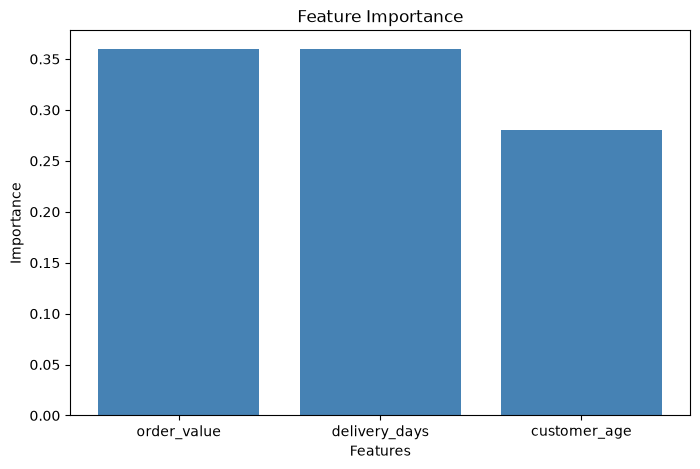

In [9]:
features = ['order_value', 'delivery_days', 'customer_age']
importances = model.feature_importances_
print(importances)
print("Feature Importances:")
for feature, importance in zip(features, importances):
    print(f"{feature}: {importance:.4f}")

plt.figure(figsize=(8, 5))
plt.bar(features, importances, color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()